In [10]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np
from tensorflow.keras.models import load_model

In [11]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32

train_df = pd.read_csv("../data/train.csv")
val_df = pd.read_csv("../data/validation.csv")
test_df = pd.read_csv("../data/test.csv")
test_df['label'] = 0

train_df["image_id"] = train_df["image_id"].apply(lambda x: os.path.join("../data/train", f"{x}.png"))
val_df["image_id"] = val_df["image_id"].apply(lambda x: os.path.join("../data/validation", f"{x}.png"))
test_df["image_id"] = test_df["image_id"].apply(lambda x: os.path.join("../data/test", f"{x}.png"))

train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)

In [12]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(
    train_df, x_col="image_id", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="sparse")

val_data = val_gen.flow_from_dataframe(
    val_df, x_col="image_id", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="sparse")

test_data = test_gen.flow_from_dataframe(
    test_df, x_col="image_id", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode=None, shuffle=False)

Found 12500 validated image filenames belonging to 5 classes.
Found 1250 validated image filenames belonging to 5 classes.
Found 6500 validated image filenames.


In [13]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(*IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

# Optimizer și callbacks
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

c:\Users\Agu\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stopping, lr_scheduler]
)

c:\Users\Agu\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 122s 304ms/step - accuracy: 0.4807 - loss: 5.0121 - val_accuracy: 0.3808 - val_loss: 2.7277 - learning_rate: 0.0010
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 110s 282ms/step - accuracy: 0.6113 - loss: 1.5935 - val_accuracy: 0.5752 - val_loss: 1.6371 - learning_rate: 0.0010
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 98s 251ms/step - accuracy: 0.6601 - loss: 1.2122 - val_accuracy: 0.5200 - val_loss: 1.6574 - learning_rate: 0.0010
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 99s 254ms/step - accuracy: 0.7013 - loss: 1.0649 - val_accuracy: 0.4616 - val_loss: 1.9199 - learning_rate: 0.0010
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 100s 255ms/step - accuracy: 0.7144 - loss: 1.0188 - val_accuracy: 0.7280 - val_loss: 0.9192 - learning_rate: 0.0010
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 99s 254ms/step - accuracy: 0.7208 - loss: 0.9704 - val_accuracy: 0.7200 - val_loss: 0.9838 - learning_rate: 0.0010
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 99s 252ms/step - accuracy: 

In [20]:
pred_probs = model.predict(test_data)
pred_labels = np.argmax(pred_probs, axis=1)

submission = pd.DataFrame({
    "image_id": test_df["image_id"].apply(lambda x: os.path.splitext(os.path.basename(x))[0]),
    "label": pred_labels
})
submission.to_csv("submission_cnn3_2.csv", index=False)


204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step


In [17]:
model.save('cnn3.keras')

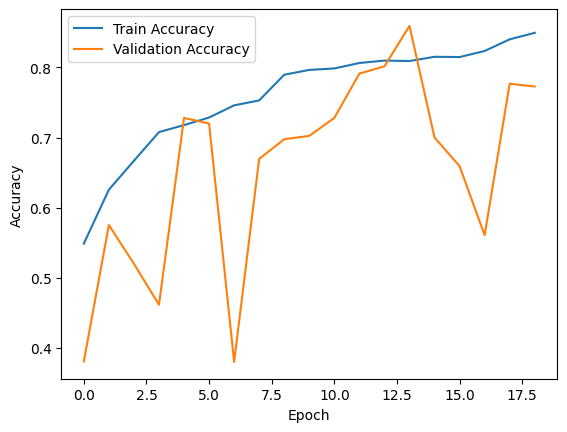

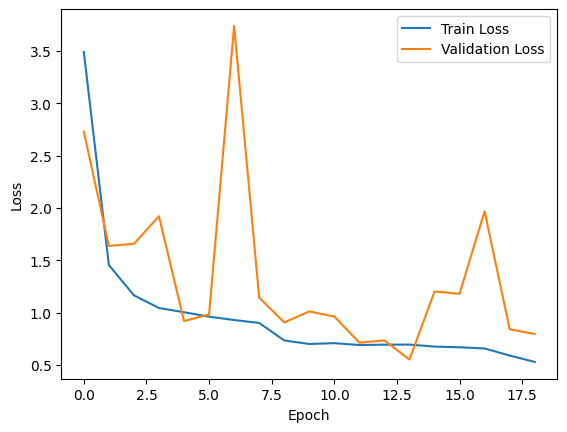

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [19]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stopping, lr_scheduler]
)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 100s 252ms/step - accuracy: 0.8121 - loss: 0.6697 - val_accuracy: 0.7640 - val_loss: 0.8934 - learning_rate: 1.0000e-05
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 101s 257ms/step - accuracy: 0.8381 - loss: 0.6000 - val_accuracy: 0.7920 - val_loss: 0.7709 - learning_rate: 1.0000e-05
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 99s 254ms/step - accuracy: 0.8382 - loss: 0.5882 - val_accuracy: 0.7936 - val_loss: 0.7446 - learning_rate: 1.0000e-05
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 101s 258ms/step - accuracy: 0.8386 - loss: 0.5849 - val_accuracy: 0.7896 - val_loss: 0.7489 - learning_rate: 1.0000e-05
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 99s 254ms/step - accuracy: 0.8390 - loss: 0.5746 - val_accuracy: 0.7920 - val_loss: 0.7433 - learning_rate: 1.0000e-05
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 99s 253ms/step - accuracy: 0.8465 - loss: 0.5588 - val_accuracy: 0.8016 - val_loss: 0.7015 - learning_rate: 1.0000e-05
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 99s